![](https://cdn.careerfoundry.com/en/wp-content/uploads/2021/05/Data_scientist_salaries_by_location-1024x904.webp)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datascience-salaries-2024/DataScience_salaries_2024.csv


# Do share a thumbs up 👍, if you like my story telling¶


# ⛏️ Handling error and warnings

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
salary_24 = pd.read_csv("/kaggle/input/datascience-salaries-2024/DataScience_salaries_2024.csv")

In [4]:
salary_24.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
3,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
4,2022,SE,FT,Lead Machine Learning Engineer,7500000,INR,95386,IN,50,IN,L


In [5]:
salary_24.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
14833,2022,MI,FT,Business Intelligence Developer,15000,USD,15000,GH,100,GH,M
14834,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
14835,2021,EN,FT,Machine Learning Developer,15000,USD,15000,TH,100,TH,L
14836,2022,EN,FT,Data Analyst,15000,USD,15000,ID,0,ID,L
14837,2020,EN,PT,ML Engineer,14000,EUR,15966,DE,100,DE,S


In [6]:
salary_24.dtypes

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Ensure plots are visible in notebooks
%matplotlib inline
sns.set(style="whitegrid")


# 1. 💵Salary Trends Over Time 📈

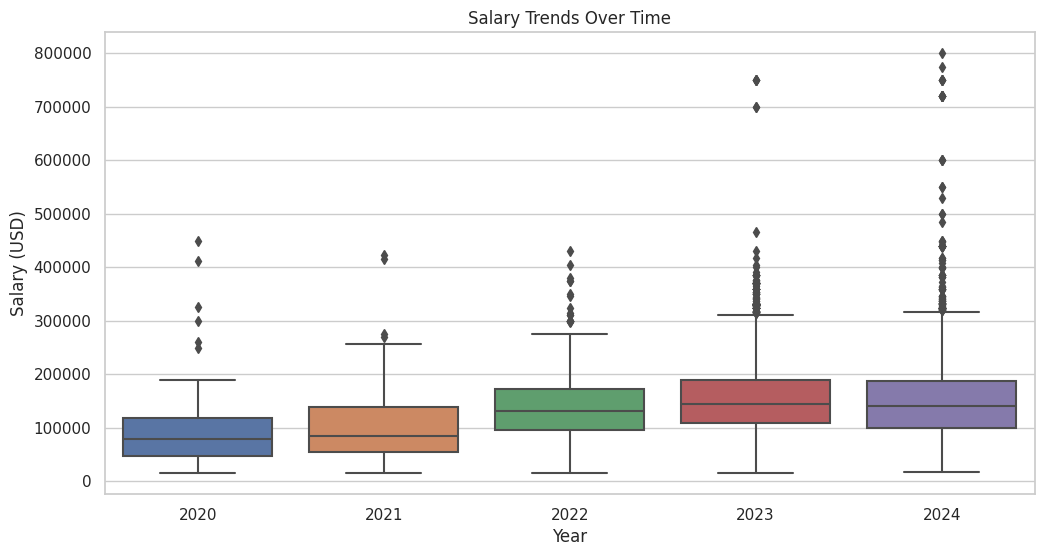

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=salary_24, x='work_year', y='salary_in_usd')
plt.title('Salary Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Salary (USD)')
plt.show()


# 2. 👩🏻‍💻 Experience Level and Salary Analysis ⏳

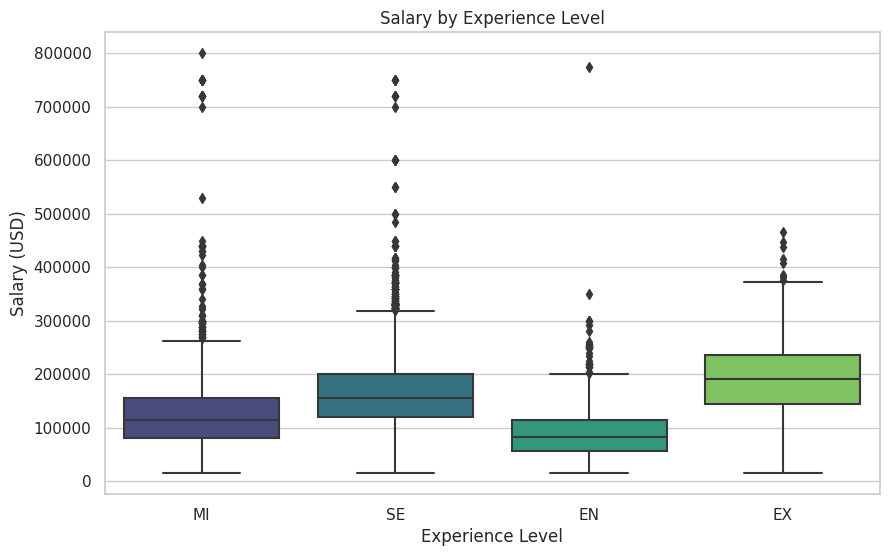

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=salary_24, x='experience_level', y='salary_in_usd', palette='viridis')
plt.title('Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()


# 3. 👔 Employment Type vs. Salary

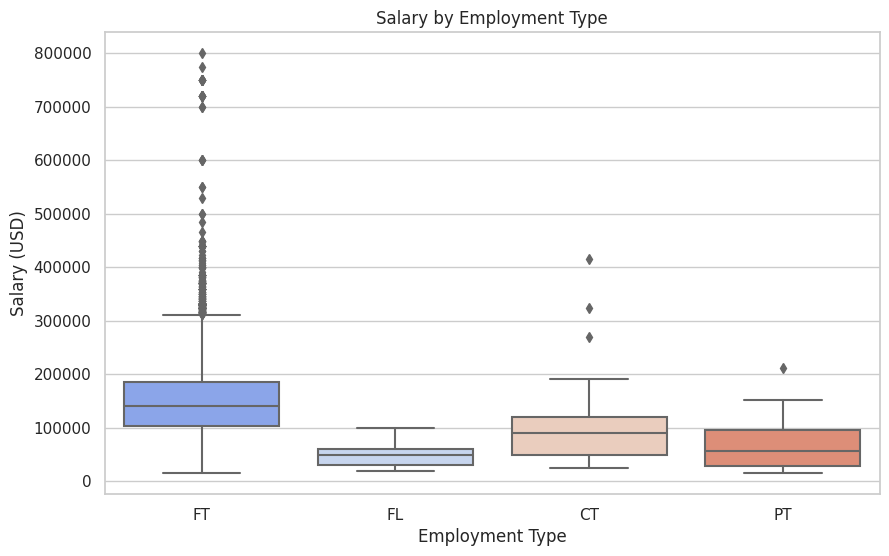

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=salary_24, x='employment_type', y='salary_in_usd', palette='coolwarm')
plt.title('Salary by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Salary (USD)')
plt.show()


# 4.  ✈︎  Remote Work Ratio Analysis

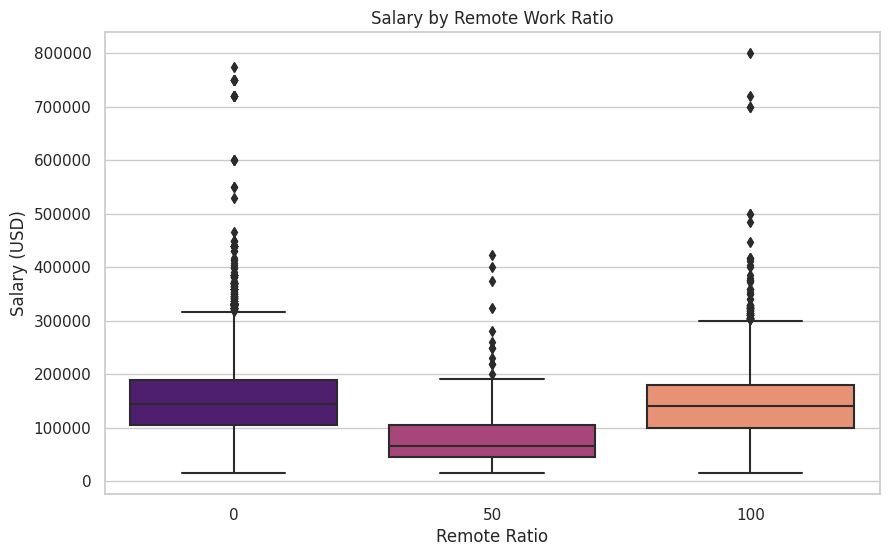

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=salary_24, x='remote_ratio', y='salary_in_usd', palette='magma')
plt.title('Salary by Remote Work Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Salary (USD)')
plt.show()


# 5. 🏢 Company Size 📏Impact on Salary

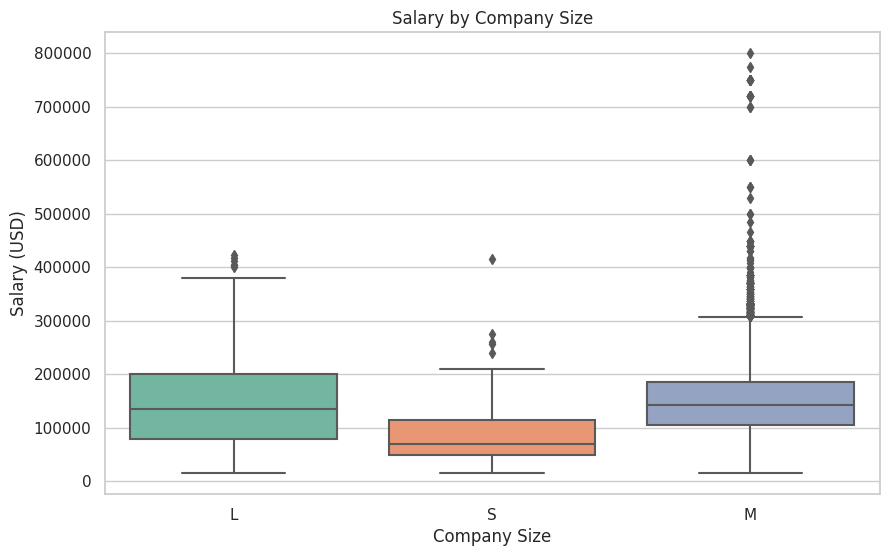

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=salary_24, x='company_size', y='salary_in_usd', palette='Set2')
plt.title('Salary by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary (USD)')
plt.show()


# 6. 📇 Job Title-Specific Salary Analysis

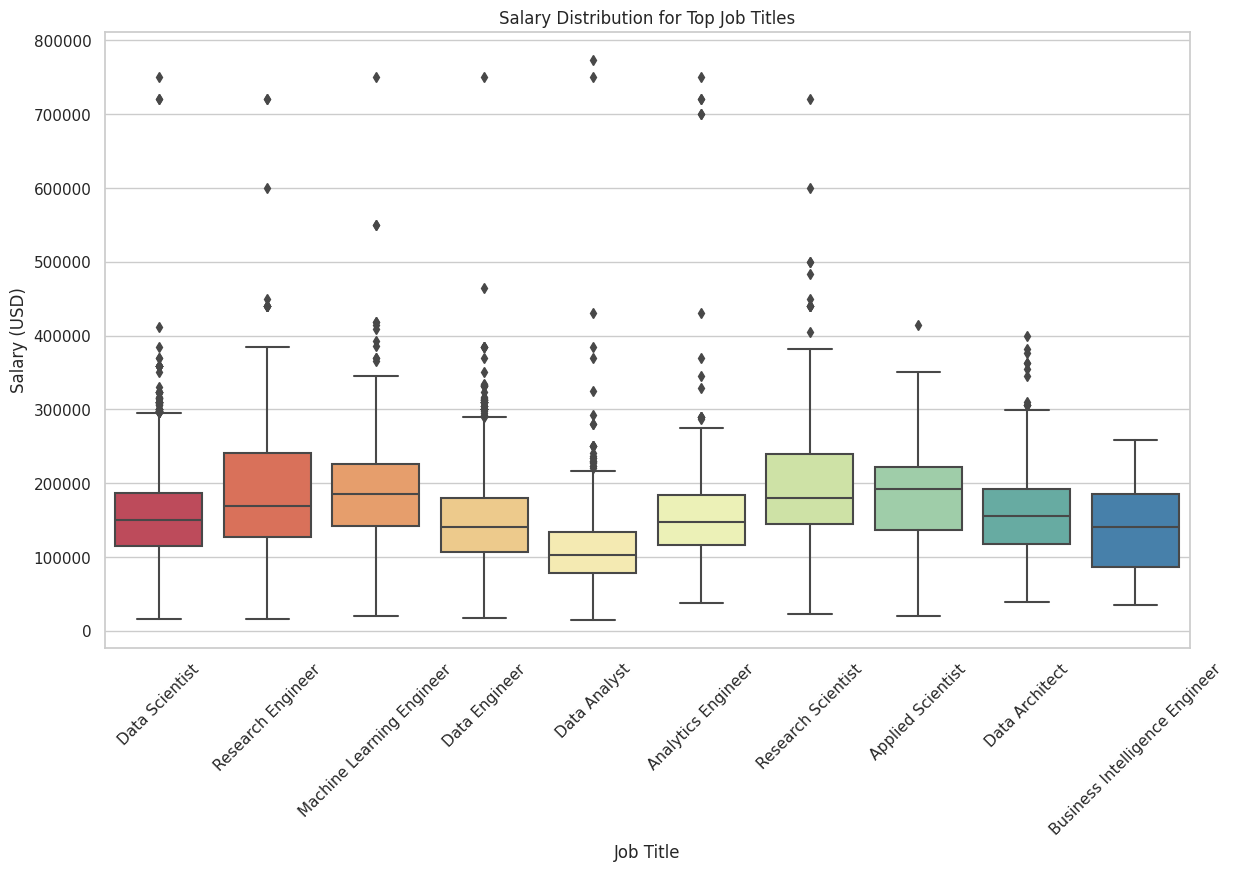

In [13]:
top_titles = salary_24['job_title'].value_counts().nlargest(10).index
df_top_titles = salary_24[salary_24['job_title'].isin(top_titles)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top_titles, x='job_title', y='salary_in_usd', palette='Spectral')
plt.xticks(rotation=45)
plt.title('Salary Distribution for Top Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Salary (USD)')
plt.show()


# 7. 🗺️⁀જ✈︎ Geographic Salary Comparison (Employee Residence vs. Company Location)

In [14]:
# Employee Residence
employee_residence_avg_salary = salary_24.groupby('employee_residence')['salary_in_usd'].mean().reset_index()
fig = px.choropleth(employee_residence_avg_salary, locations='employee_residence', 
                    locationmode='country names', color='salary_in_usd', 
                    color_continuous_scale='Viridis', title="Average Salary by Employee Residence")
fig.show()

# Company Location
company_location_avg_salary = salary_24.groupby('company_location')['salary_in_usd'].mean().reset_index()
fig = px.choropleth(company_location_avg_salary, locations='company_location', 
                    locationmode='country names', color='salary_in_usd', 
                    color_continuous_scale='Cividis', title="Average Salary by Company Location")
fig.show()


In [15]:
salary_24.company_location.unique()

array(['CL', 'US', 'HU', 'JP', 'IN', 'ID', 'DE', 'CH', 'IL', 'SG', 'AS',
       'NO', 'TH', 'PH', 'CA', 'MX', 'ZA', 'HK', 'TR', 'GB', 'QA', 'AU',
       'DK', 'ES', 'FR', 'EG', 'UA', 'RU', 'PL', 'NZ', 'NG', 'PR', 'BR',
       'SA', 'IE', 'NL', 'CO', 'SE', 'BA', 'AE', 'LT', 'PT', 'MU', 'CZ',
       'FI', 'IR', 'DZ', 'IQ', 'CN', 'AR', 'HR', 'SI', 'LB', 'AT', 'VN',
       'KE', 'GR', 'BE', 'MT', 'LV', 'IT', 'GI', 'RO', 'EE', 'LU', 'KR',
       'AM', 'AD', 'OM', 'BS', 'CF', 'PK', 'MY', 'GH', 'HN', 'MD', 'EC'],
      dtype=object)

In [16]:
# Calculate average salary by country
country_avg_salary = salary_24.groupby('employee_residence')['salary_in_usd'].mean().reset_index()
country_avg_salary.columns = ['country', 'avg_salary']

In [17]:
country_avg_salary

,country,avg_salary
0,AD,50745.000000
1,AE,86000.000000
2,AM,33500.000000
3,AR,62272.727273
4,AS,45555.000000
...,...,...
83,UG,36000.000000
84,US,157701.911032
85,UZ,82000.000000
86,VN,56733.333333


In [18]:
!pip install pycountry


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 44.2 MB/s eta 0:00:00


In [19]:
import pycountry


# 🌍❤️ Salary by Country  📍

In [20]:
#Convert ISO-2 to ISO-3 using pycountry
def convert_iso2_to_iso3(country_code):
    try:
        return pycountry.countries.get(alpha_2=country_code).alpha_3
    except AttributeError:
        return None

# Apply conversion
country_avg_salary['country_iso3'] = country_avg_salary['country'].apply(convert_iso2_to_iso3)

# Create a choropleth map with ISO-3 codes
fig = px.choropleth(
    country_avg_salary,
    locations='country_iso3',     # Use ISO-3 country codes
    locationmode='ISO-3',
    color='avg_salary',
    color_continuous_scale='Viridis',
    title="Average Salary by Country"
)

# Update layout
fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="LightGray")
fig.update_layout(title_x=0.5)
fig.show()

# 8. 💱 Currency Impact on Salary Reporting 📢

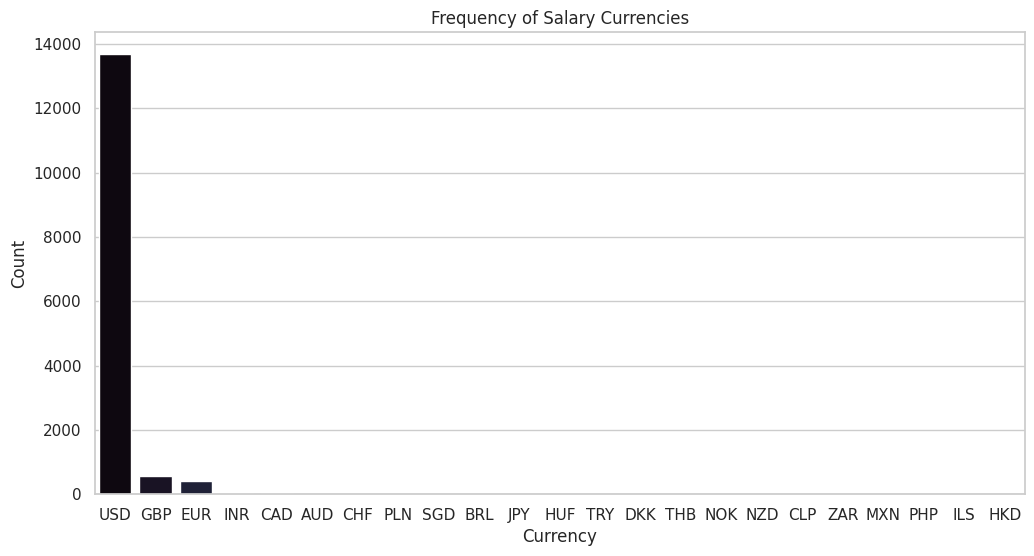

In [21]:
currency_count = salary_24['salary_currency'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=currency_count.index, y=currency_count.values, palette='cubehelix')
plt.title('Frequency of Salary Currencies')
plt.xlabel('Currency')
plt.ylabel('Count')
plt.show()


# 9. 💶 Salary Distribution Analysis 👨🏻‍💻😎🪙

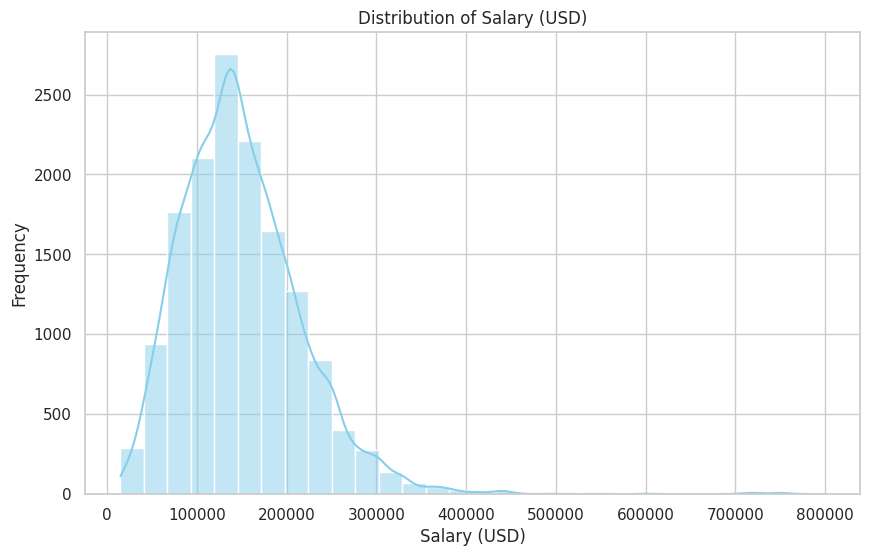

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(salary_24['salary_in_usd'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Salary (USD)')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()


# 10. 🌀 Experience and Employment Type Combined Impact on Salary 🔮

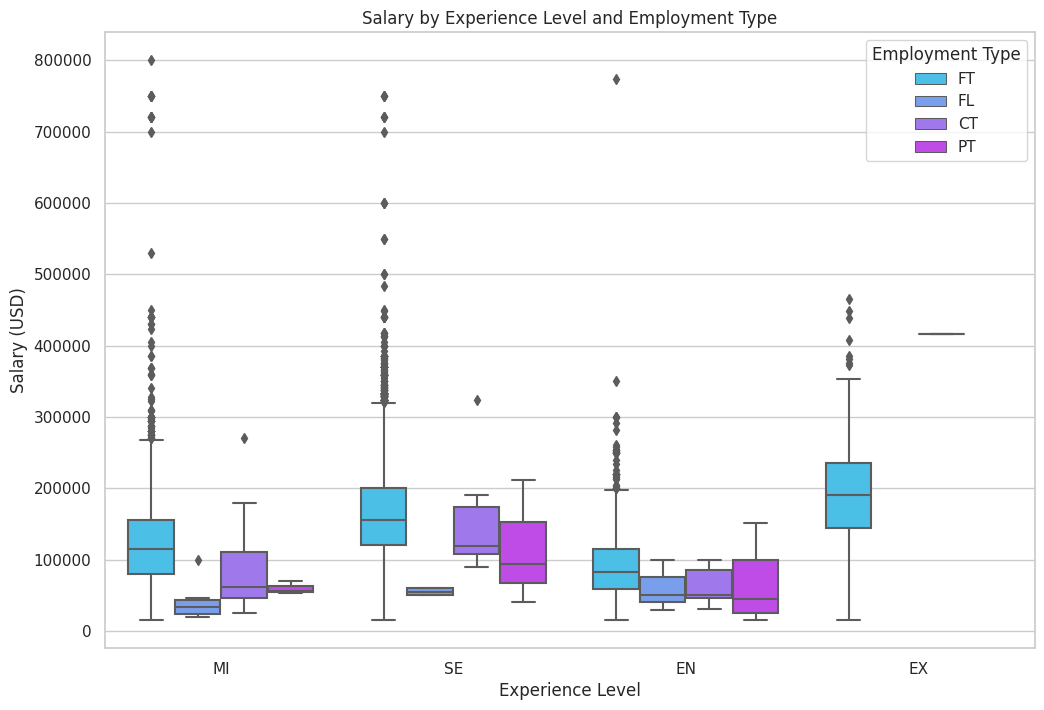

In [23]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=salary_24, x='experience_level', y='salary_in_usd', hue='employment_type', palette='cool')
plt.title('Salary by Experience Level and Employment Type')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.legend(title='Employment Type')
plt.show()


# Do share a thumbs up 👍, if you like my story telling¶
